# X-OPT - TSPLIB FACILITY REMOVAL REOPTIMIZATION INSTANCE PLOTS

This notebook visualizes one geometric TSPLIB instance from notebook `5.2`. For a configurable source instance and a facility index `x` in the sorted metaheuristic best solution, it plots:

1. The metaheuristic best solution used as the reference solution;
2. The replacement candidate pool used by each reoptimization variant after removing the facility at position `x`;
3. The reoptimized solution returned by each variant, with its assignment cost in the subplot title.

The notebook reads the CSV artifacts already written by `5.2`; it does not run the metaheuristic or rebuild the long-term-memory structures.

### SETUP

In [1]:
from __future__ import annotations

import os
import sys
import math

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt

from pathlib          import Path
from matplotlib.lines import Line2D

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "experiments_sbpo" / "lib").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing notebooks/experiments_sbpo/lib."
    )


PROJECT_ROOT = find_repo_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "experiments_sbpo"

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

In [3]:
from lib.tsplib import TSPLIBInstanceSpec  , \
                       assignment_profile  , \
                       load_tsplib_instance


OUTPUT_DIR      = PROJECT_ROOT / "notebooks" / "experiments_sbpo" / "artifacts"
RAW_RESULTS_CSV = OUTPUT_DIR   / "facility_removal_tsplib_group_raw.csv"

if not RAW_RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"Missing {RAW_RESULTS_CSV}. Run notebook 5.2 first or restore its artifacts."
    )

print(f"Project root: {PROJECT_ROOT   }")
print(f"Input CSV   : {RAW_RESULTS_CSV}")

Project root: /home/rei-luisinho/xopt
Input CSV   : /home/rei-luisinho/xopt/notebooks/experiments_sbpo/artifacts/facility_removal_tsplib_group_raw.csv


### CONFIGURATION


In [4]:
INSTANCE_NAME    =     os.environ.get("FACREM_TSPLIB_PLOT_INSTANCE"        , "kroB200")
FACILITY_INDEX_X = int(os.environ.get("FACREM_TSPLIB_PLOT_FACILITY_INDEX_X", "2"     ))

ASSIGNMENT_LINE_MAX = int(os.environ.get("FACREM_TSPLIB_PLOT_LINE_MAX", "900"))

VARIANT_LABELS = {
    "baseline_all_facilities"        : "baseline_all_facilities"       ,
    "max_k_cut_original"             : "max_k_cut_original"            ,
    "max_k_cut_mst_trajectory"       : "max_k_cut_mst_trajectory"      ,
    "max_k_cut_pairwise_trajectory"  : "max_k_cut_pairwise_trajectory" ,
    "max_k_cut_mst_range_guard"      : "max_k_cut_mst_range_guard"     ,
    "max_k_cut_pairwise_range_guard" : "max_k_cut_pairwise_range_guard",
    "random_original_pool_size"      : "random_original_pool_size"     ,
    "nearest_original_pool_size"     : "nearest_original_pool_size"    ,
}

print(f"Instance: {INSTANCE_NAME   }")
print(f"x       : {FACILITY_INDEX_X}")

Instance: kroB200
x       : 2


### LOAD SCENARIO

In [5]:
def parse_facility_list(value: object) -> tuple[int, ...]:
    if value is None:
        return tuple()

    if isinstance(value, float) and pd.isna(value):
        return tuple()

    text = str(value).strip()

    if not text or text.lower() == "nan":
        return tuple()

    values = [
        int(part)
        for part in text.replace(",", " ").split()
    ]

    return tuple(sorted(dict.fromkeys(values)))


def compact_facilities(
    facilities: tuple[int, ...] | list[int],
    *,
    one_based : bool = False,
    max_items : int  = 24   ,
) -> str:
    values = tuple(int(value) for value in facilities)
    offset = 1 if one_based else 0
    shown  = values[:max_items]
    text   = " ".join(str(value + offset) for value in shown)

    if len(values) > max_items:
        text = f"{text} ..."

    return text


def format_variant(value: str) -> str:
    return VARIANT_LABELS.get(str(value), str(value))


def format_cost(value: object) -> str:
    try:
        cost = float(value)
    except (TypeError, ValueError):
        return "NA"

    if not np.isfinite(cost):
        return "NA"

    return f"{cost:,.0f}"


raw_results_df = pd.read_csv(RAW_RESULTS_CSV)

scenario_df = raw_results_df.loc[
    (raw_results_df["instance"] == INSTANCE_NAME) & (raw_results_df["removal_position"].astype(int) == FACILITY_INDEX_X)
].copy()

if scenario_df.empty:
    available = (
        raw_results_df[["instance", "removal_position"]]
        .drop_duplicates()
        .sort_values    (["instance", "removal_position"])
        .head           (30)
    )

    raise ValueError(
        "No rows found for the selected instance/removal position. "
        f"First available pairs:\n{available.to_string(index=False)}"
    )

scenario_df = (
    scenario_df
    .sort_values("variant_order", kind="stable")
    .reset_index(drop=True)
)

scenario              = scenario_df.iloc[0]
reference_facilities  = parse_facility_list(scenario["reference_facilities"          ])
remaining_reference   = parse_facility_list(scenario["remaining_reference_facilities"])

removed_facility      = int(scenario["removed_facility_zero_based"])
removed_facility_name = removed_facility + 1

if FACILITY_INDEX_X < 0 or FACILITY_INDEX_X >= len(reference_facilities):
    raise ValueError(
        f"x={FACILITY_INDEX_X} is outside the reference solution size "
        f"{len(reference_facilities)}."
    )

print(f"Reference solution, zero-based: {compact_facilities(reference_facilities                )}")
print(f"Reference solution, one-based : {compact_facilities(reference_facilities, one_based=True)}")
print(
    f"x={FACILITY_INDEX_X} removes facility {removed_facility} "
    f"(one-based {removed_facility_name})."
)

Reference solution, zero-based: 28 41 68 83 95
Reference solution, one-based : 29 42 69 84 96
x=2 removes facility 68 (one-based 69).


In [6]:
raw_path = Path(str(scenario["raw_path"]))

if not raw_path.is_absolute():
    raw_path = PROJECT_ROOT / raw_path

spec = TSPLIBInstanceSpec(
    name             = str(scenario["instance"        ]),
    dimension        = int(scenario["n"               ]),
    edge_weight_type = str(scenario["edge_weight_type"]).upper(),
    p                = int(scenario["p"               ]),
    url              = ""      ,
    raw_path         = raw_path,
)

instance = load_tsplib_instance(spec)
points   = instance.points.copy(    )
n_nodes  = len(points)


def candidate_pool_from_row(row: pd.Series) -> tuple[int, ...]:
    explicit_pool = parse_facility_list(row.get("max_k_cut_replacement_pool"))
    strategy      = str(row.get("replacement_pool_strategy", ""))

    if explicit_pool or strategy != "all_facilities":
        return explicit_pool

    fixed     = set(parse_facility_list(row.get("fixed_facilities"    )))
    forbidden = set(parse_facility_list(row.get("forbidden_facilities")))

    return tuple(
        node
        for node in range(n_nodes)
        if  node not in fixed and node not in forbidden
    )


scenario_df["candidate_pool"     ] = scenario_df.apply(candidate_pool_from_row, axis=1)
scenario_df["solution_facilities"] = scenario_df["open_facilities"].map(parse_facility_list)
scenario_df["pool_size_check"    ] = scenario_df["candidate_pool" ].map(len                )

print(f"Loaded {instance.name} with {n_nodes} nodes and p={instance.p}.")

Loaded tsplib_kroB200_p5 with 200 nodes and p=5.


In [7]:
summary_table = pd.DataFrame(
    {
        "variant"                   : scenario_df["variant"            ].map(format_variant    ),
        "candidate_pool_size"       : scenario_df["candidate_pool"     ].map(len               ),
        "candidate_pool_zero_based" : scenario_df["candidate_pool"     ].map(compact_facilities),
        "solution_zero_based"       : scenario_df["solution_facilities"].map(compact_facilities),
        "cost"                      : scenario_df["objective_value"    ].map(format_cost       ),
    }
)

display(summary_table)

,variant,candidate_pool_size,candidate_pool_zero_based,solution_zero_based,cost
0,baseline_all_facilities,195,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18...,28 41 83 95 133,"97,665"
1,max_k_cut_original,4,29 74 133 149,28 41 83 95 133,"97,665"
2,max_k_cut_mst_trajectory,4,29 74 133 149,28 41 83 95 133,"97,665"
3,max_k_cut_pairwise_trajectory,4,29 74 133 149,28 41 83 95 133,"97,665"
4,max_k_cut_mst_range_guard,4,29 74 133 149,28 41 83 95 133,"97,665"
5,max_k_cut_pairwise_range_guard,4,29 74 133 149,28 41 83 95 133,"97,665"
6,random_original_pool_size,4,53 66 72 91,28 41 66 83 95,"109,370"
7,nearest_original_pool_size,4,25 99 100 149,28 41 83 95 149,"97,958"


### PLOT HELPERS

In [8]:
POINT_COLOR   = "#d0d0d0"
POOL_COLOR    = "#2b8cbe"
FIXED_COLOR   = "#111111"
REMOVED_COLOR = "#d73027"
REPLACE_COLOR = "#1a9850"
EDGE_COLOR    = "#ffffff"


def axis_limits(
    data         : pd.DataFrame,
    *,
    pad_fraction : float = 0.07,
) -> tuple[tuple[float, float], tuple[float, float]]:
    x_min, x_max = data["long"].min(), data["long"].max()
    y_min, y_max = data["lat" ].min(), data["lat" ].max()

    x_pad = max(1e-6, (x_max - x_min) * pad_fraction)
    y_pad = max(1e-6, (y_max - y_min) * pad_fraction)

    return (x_min - x_pad, x_max + x_pad), (y_min - y_pad, y_max + y_pad)


def setup_geometry_axis(ax, title: str) -> None:
    xlim, ylim = axis_limits(points)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.grid     (alpha=0.10, linewidth=0.6)
    ax.set_title(title     , fontsize =9  )


def point_subset(facilities: tuple[int, ...] | list[int]) -> pd.DataFrame:
    return points[points["node"].isin(set(int(value) for value in facilities))]


def draw_base_points(ax, *, alpha: float = 0.68, size: float = 14) -> None:
    ax.scatter(
        points["long"],
        points["lat" ],
        s         = size       ,
        c         = POINT_COLOR,
        edgecolor = "none"     ,
        alpha     = alpha      ,
        zorder    = 1,
    )


def draw_facility_markers(
    ax,
    facilities: tuple[int, ...] | list[int],
    *,
    color     : str  ,
    marker    : str  ,
    size      : float,
    label     : str  ,
    zorder    : int   = 4   ,
    linewidth : float = 0.75,
) -> None:
    selected_points = point_subset(facilities)

    if selected_points.empty:
        return

    ax.scatter(
        selected_points["long"],
        selected_points["lat" ],
        s         = size  ,
        c         = color ,
        marker    = marker,
        edgecolor = EDGE_COLOR,
        linewidth = linewidth ,
        label     = label ,
        zorder    = zorder,
    )


def annotate_facilities(
    ax,
    facilities: tuple[int, ...] | list[int],
    *,
    max_labels: int = 16,
    color     : str = "#111111",
) -> None:
    values = tuple(int(value) for value in facilities)

    if len(values) > max_labels:
        return

    for row in point_subset(values).itertuples(index=False):
        ax.annotate(
            str(int(row.node) + 1),
            (row.long, row.lat),
            xytext     = (4, 4),
            textcoords = "offset points",
            fontsize   = 7    ,
            zorder     = 8    ,
            color      = color,
        )


def solution_assignments(
    facilities: tuple[int, ...] | list[int],
) -> tuple[float, np.ndarray]:
    cost, assignments, _, _, _ = assignment_profile(
        instance,
        tuple(int(value) for value in facilities),
    )

    return float(cost), assignments


def selected_color_map(
    facilities: tuple[int, ...] | list[int],
) -> dict[int, object]:
    selected = tuple(sorted(int(value) for value in facilities))

    palette  = plt.colormaps["tab10"].resampled(max(1, len(selected)))

    return {
        facility : palette(index)
        for index, facility in enumerate(selected)
    }


def sampled_nodes(limit: int = ASSIGNMENT_LINE_MAX, seed: int = 42) -> np.ndarray:
    if n_nodes <= limit:
        return np.arange(n_nodes, dtype=int)

    rng = np.random.default_rng(seed)

    return np.sort(
        rng.choice(np.arange(n_nodes, dtype=int), size=int(limit), replace=False)
    )


def plot_solution(
    ax,
    facilities : tuple[int, ...] | list[int],
    *,
    title      : str,
    cost_value : object | None = None,
) -> None:
    facilities = tuple(sorted(int(value) for value in facilities))

    cost, assignments = solution_assignments(facilities)
    display_cost      = cost if cost_value is None else cost_value

    setup_geometry_axis(ax, f"{title}\ncost={format_cost(display_cost)}")

    colors_by_facility = selected_color_map(facilities)
    points_by_node     = points.set_index("node", drop=False)

    for node in sampled_nodes().tolist():
        facility = int(assignments[node])

        if node == facility:
            continue

        p1 = points_by_node.loc[node    ]
        p2 = points_by_node.loc[facility]

        ax.plot(
            [p1["long"], p2["long"]],
            [p1["lat" ], p2["lat" ]],
            color     = colors_by_facility.get(facility, "#999999"),
            linewidth = 0.42,
            alpha     = 0.22,
            zorder    = 1   ,
        )

    node_colors = [
        colors_by_facility.get(
            int(assignments[int(node)]), "#999999"
        )
        for node in points["node"]
    ]

    ax.scatter(
        points["long"],
        points["lat" ],
        s         = 16  ,
        alpha     = 0.70,
        zorder    = 2   ,
        edgecolor = "none"     ,
        c         = node_colors,
    )

    draw_facility_markers(
        ax        ,
        facilities,
        marker = "*",
        size   = 170,
        zorder = 5  ,
        color  = "#111111"    ,
        label  = "open facility",
    )
    annotate_facilities(ax, facilities, max_labels=12)


def plot_candidate_pool(ax, row: pd.Series) -> None:
    pool       = tuple(row["candidate_pool"     ])
    solution   = tuple(row["solution_facilities"])

    fixed      = parse_facility_list(row["fixed_facilities"    ])
    forbidden  = parse_facility_list(row["forbidden_facilities"])

    new_open   = tuple(sorted(set(solution) - set(fixed)))
    title      = f"{format_variant(row['variant'])}\n|C|={len(pool)}"

    setup_geometry_axis(ax, title)
    draw_base_points   (ax, alpha=0.56, size=12)

    if pool:
        pool_points = point_subset(pool)

        ax.scatter(
            pool_points["long"],
            pool_points["lat" ],
            c         = POOL_COLOR,
            marker    = "o"       ,
            zorder    = 3         ,
            s         = 34   if len(pool) <= 40  else 16  ,
            linewidth = 0.35 if len(pool) <= 500 else 0.0 ,
            alpha     = 0.82 if len(pool) <= 500 else 0.52,
            edgecolor = EDGE_COLOR if len(pool) <= 500 else "none",
        )

    draw_facility_markers(
        ax   ,
        fixed,
        color  = FIXED_COLOR,
        label  = "fixed"    ,
        marker = "*",
        size   = 150,
        zorder = 5  ,
    )
    draw_facility_markers(
        ax       ,
        forbidden,
        color  = REMOVED_COLOR,
        label  = "removed"    ,
        marker = "X",
        size   = 125,
        zorder = 6  ,
    )
    draw_facility_markers(
        ax      ,
        new_open,
        color  = REPLACE_COLOR       ,
        label  = "chosen replacement",
        marker = "D",
        size   = 76 ,
        zorder = 7  ,
    )

    annotate_facilities(ax, pool     , max_labels=10, color=POOL_COLOR   )
    annotate_facilities(ax, fixed    , max_labels=12, color=FIXED_COLOR  )
    annotate_facilities(ax, forbidden, max_labels=12, color=REMOVED_COLOR)


def subplot_grid(
    count: int,
    *,
    columns    : int   = 4  ,
    cell_width : float = 4.2,
    cell_height: float = 3.8,
):
    columns = min(columns, max(1, int(count)))
    rows    = int(math.ceil(count / columns ))

    fig, axes = plt.subplots(
        rows   ,
        columns,
        squeeze=False,
        figsize=(cell_width * columns, cell_height * rows),
    )

    return fig, axes

### METAHEURISTIC BEST SOLUTION

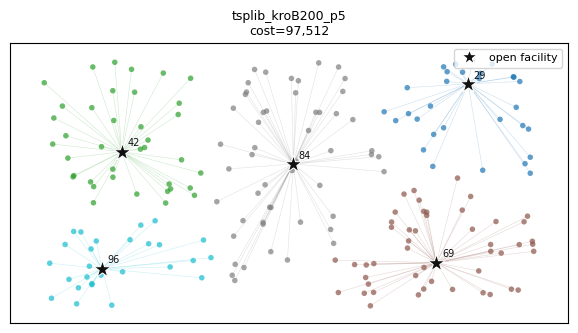

In [9]:
reference_cost = float(scenario["reference_cost"])

fig, ax = plt.subplots(figsize=(7.2, 6.4))

plot_solution(
    ax                  ,
    reference_facilities,
    cost_value = reference_cost    ,
    title      = f"{instance.name}",
)

ax.legend(
    handles=[
        Line2D(
            [0], [0],
            marker          = "*"        ,
            color           = "none"     ,
            markerfacecolor = "#111111",
            markeredgecolor = EDGE_COLOR ,
            markersize      = 12         ,
            label           = "open facility",
        )
    ],
    loc       = "upper right",
    frameon   = True,
    fontsize  = 8   ,
)

plt.show()

### CANDIDATE POOLS FOR X

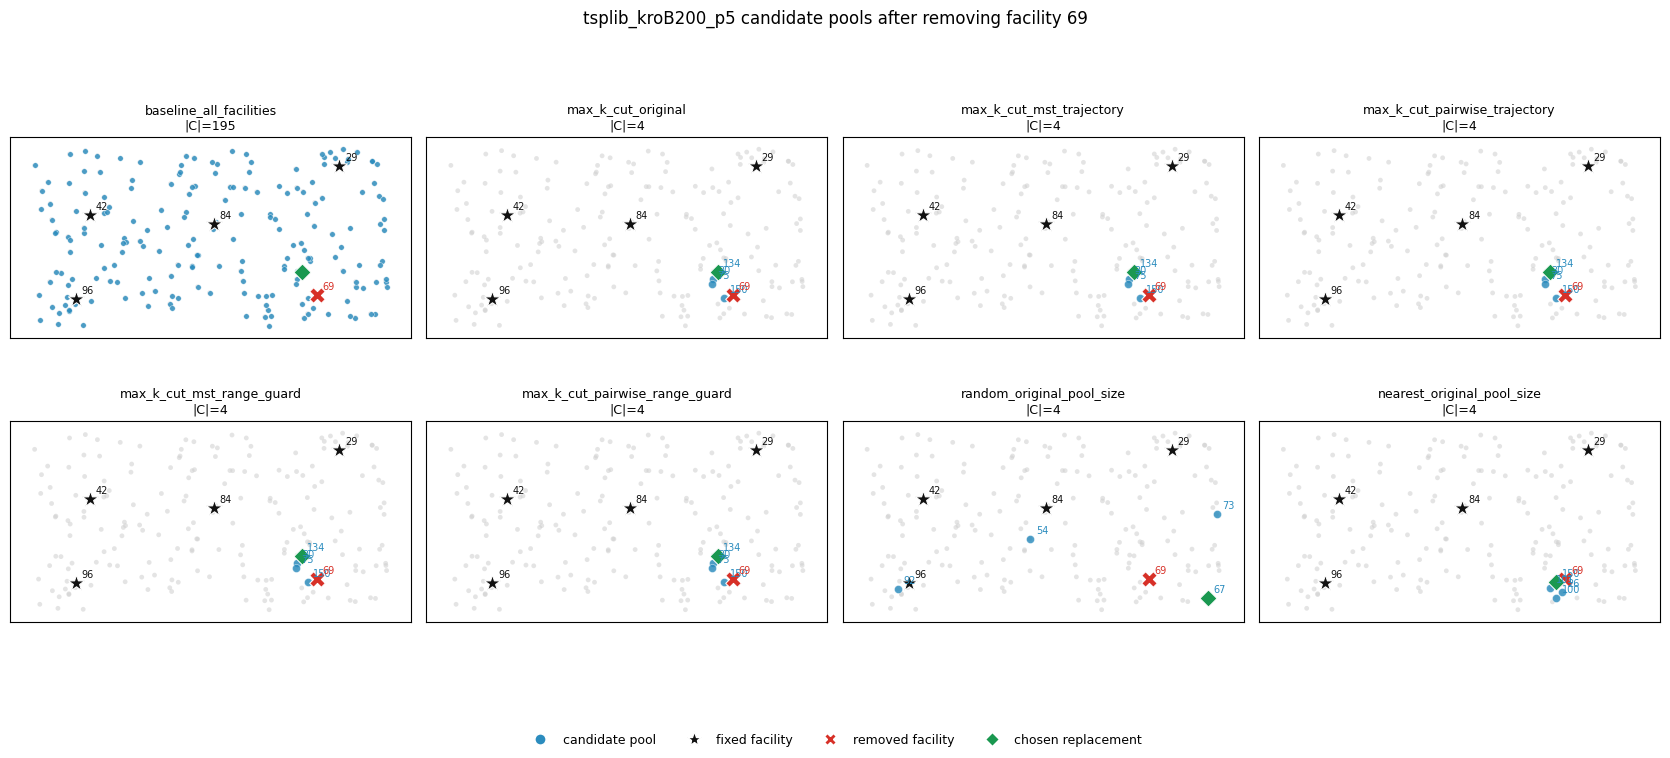

In [10]:
fig, axes = subplot_grid(len(scenario_df), columns=4)

for ax, (_, row) in zip(axes.flat, scenario_df.iterrows()):
    plot_candidate_pool(ax, row)

for ax in axes.flat[len(scenario_df):]:
    ax.axis("off")

handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=POOL_COLOR   , markeredgecolor=EDGE_COLOR, markersize=8 , label="candidate pool"    ),
    Line2D([0], [0], marker="*", color="none", markerfacecolor=FIXED_COLOR  , markeredgecolor=EDGE_COLOR, markersize=11, label="fixed facility"    ),
    Line2D([0], [0], marker="X", color="none", markerfacecolor=REMOVED_COLOR, markeredgecolor=EDGE_COLOR, markersize=9 , label="removed facility"  ),
    Line2D([0], [0], marker="D", color="none", markerfacecolor=REPLACE_COLOR, markeredgecolor=EDGE_COLOR, markersize=7 , label="chosen replacement"),
]

fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=9)

fig.suptitle(
    f"{instance.name} candidate pools after removing facility {removed_facility_name}", fontsize=12
)

fig.tight_layout(rect=(0, 0.05, 1, 0.98))

plt.show()

### REOPTIMIZED SOLUTIONS BY VARIANT

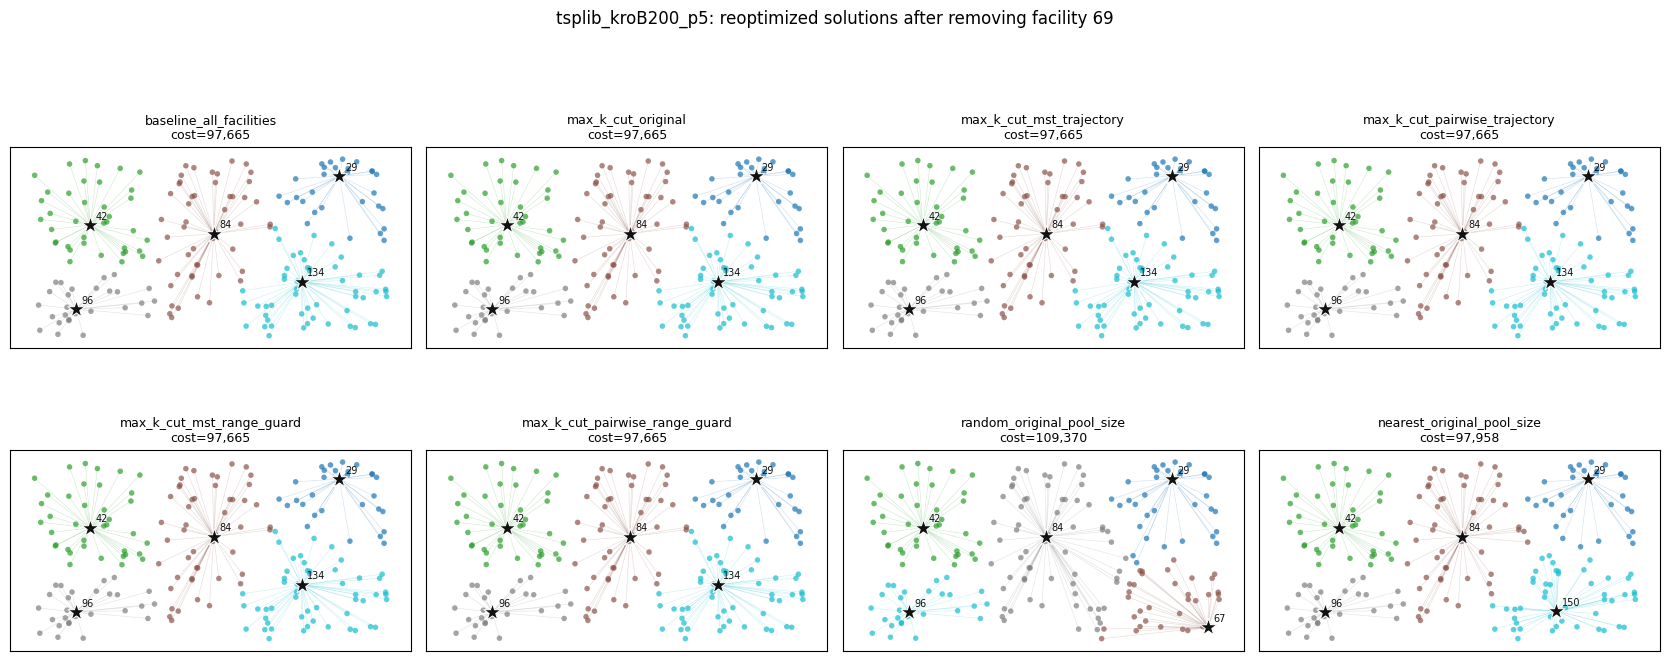

In [11]:
fig, axes = subplot_grid(len(scenario_df), columns=4)

for ax, (_, row) in zip(axes.flat, scenario_df.iterrows()):
    plot_solution(
        ax                        ,
        row["solution_facilities"],
        title     =format_variant(row["variant"        ]),
        cost_value=               row["objective_value"] ,
    )

for ax in axes.flat[len(scenario_df):]:
    ax.axis("off")

fig.suptitle(
    f"{instance.name}: reoptimized solutions after removing facility {removed_facility_name}", fontsize=12
)

fig.tight_layout(rect=(0, 0.00, 1, 0.98))

plt.show()